In [1]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import random
import os

myutils.set_figure_params()
sc.settings.verbosity = 3

In [2]:
adata = sc.read_h5ad("./3.1.fibroblast_final.h5ad")
adata

AnnData object with n_obs × n_vars = 26710 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final', 'leiden1.0', 'CellType2'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType2_colors', 'CellType_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden', 'leiden1.0', 'leiden1.0_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
all_colors = ["#96C3D8","#5D9BBE","#F5B375","#C0937E","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
#all_colors = ["#96C3D8","#5D9BBE","#F5B375","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
all_colors = np.array(all_colors)
use_colors = np.linspace(0,len(all_colors)-1,len(adata.obs['CellType2'].unique()))
use_colors = np.array(use_colors,dtype="int")
use_colors = all_colors[use_colors]
adata.uns['CellType2_colors'] = use_colors
use_colors

array(['#96C3D8', '#F58135'], dtype='<U7')

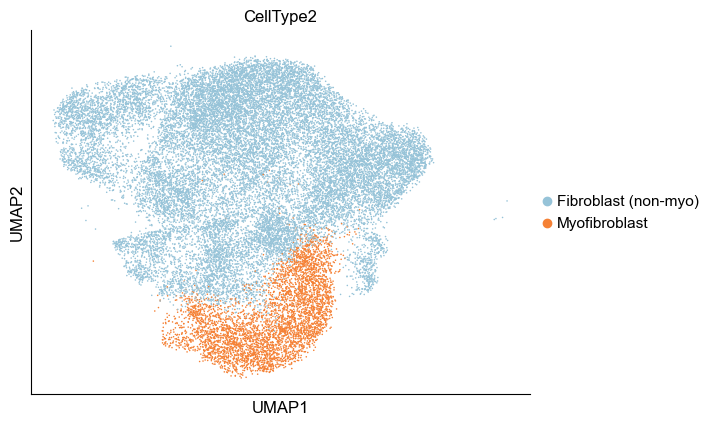

In [4]:
fig,ax = plt.subplots()
sc.pl.embedding(adata,"umap",color=["CellType2"],ax=ax,show=False,size=5.)
fig.savefig("3.2.Figure1D.pdf",format="pdf",bbox_inches="tight")
plt.show()

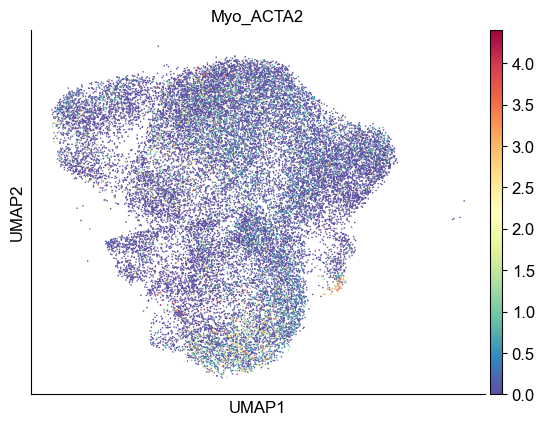

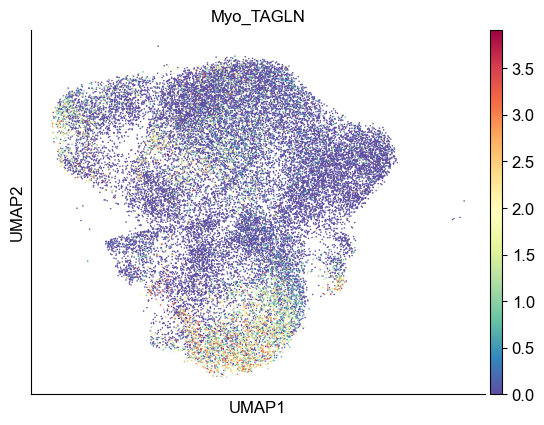

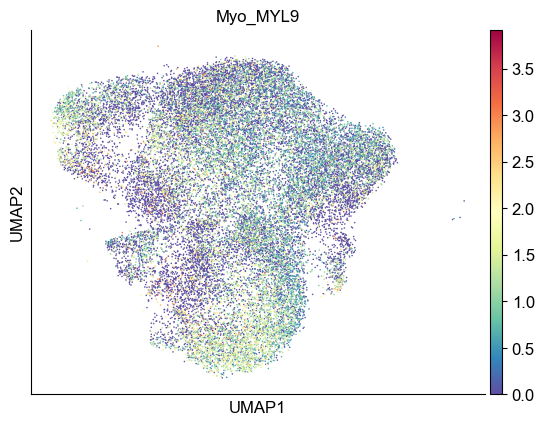

In [8]:
markers = {"Myo":["ACTA2","TAGLN","MYL9"]}
for group in markers.keys():
    genes = markers[group]
    for gene in genes:
        fig,ax = plt.subplots()
        sc.pl.embedding(adata,"umap",color=gene,ax=ax,show=False,size=5.,title=group+"_"+gene)
        fig.savefig("./10.4.fibroblast_"+group+"_"+gene+".pdf",format="pdf",bbox_inches="tight")
        plt.show()

In [5]:
sc.tl.embedding_density(adata,groupby="condition")

computing density on 'umap'
--> added
    'umap_density_condition', densities (adata.obs)
    'umap_density_condition_params', parameter (adata.uns)


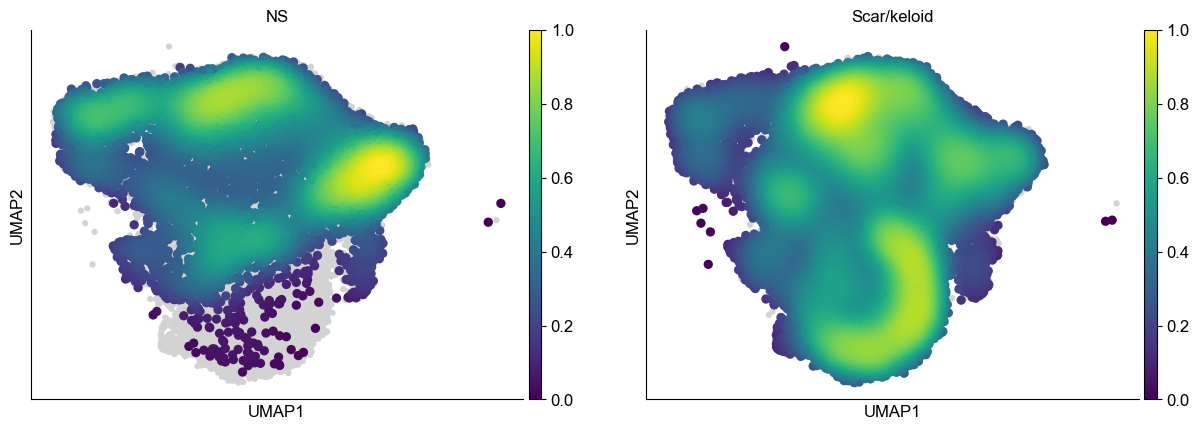

In [7]:
sc.pl.embedding_density(adata,groupby="condition",color_map="viridis",save="Figure1E.pdf")

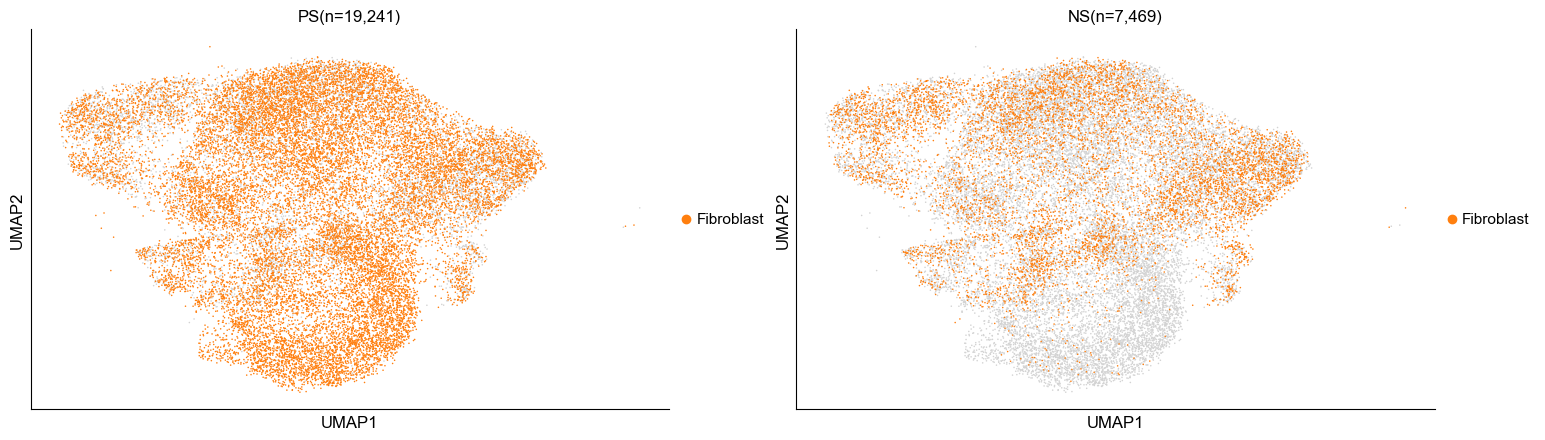

In [11]:
fig,axs = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(18)

sc.pl.embedding(adata[adata.obs['condition']!="Scar/keloid"],"umap",ax=axs[0],show=False,size=5.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="Scar/keloid"],"umap",color=["CellType"],ax=axs[0],show=False,size=5.,title=None)
axs[0].set_title("PS(n=19,241)")

sc.pl.embedding(adata[adata.obs['condition']!="NS"],"umap",ax=axs[1],show=False,size=5.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="NS"],"umap",color=["CellType"],ax=axs[1],show=False,size=5.,title=None)
axs[1].set_title("NS(n=7,469)")

fig.savefig("3.2.FigureS1E.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [12]:
markers = myutils.tl.scanpy_ranking_genes(adata,group_by="CellType2",calculate_average_expression=False,save="10.4.markers_fibroblast.tsv")
markers.head(5)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


,Fibroblast (non-myo)_names,Fibroblast (non-myo)_scores,Fibroblast (non-myo)_pvals_adj,Fibroblast (non-myo)_logfoldchanges,Myofibroblast_names,Myofibroblast_scores,Myofibroblast_pvals_adj,Myofibroblast_logfoldchanges
0,APOD,124.600693,0.0,3.816529,COL1A1,168.536407,0.0,3.561998
1,CFD,102.946655,0.0,3.628808,SPARC,163.991653,0.0,3.379489
2,GSN,97.563904,0.0,2.484265,COL1A2,156.925079,0.0,2.845717
3,SELENOP,97.342712,0.0,2.925336,COL3A1,147.978027,0.0,3.037116
4,C3,96.887886,0.0,3.698814,CTHRC1,142.022141,0.0,4.140112


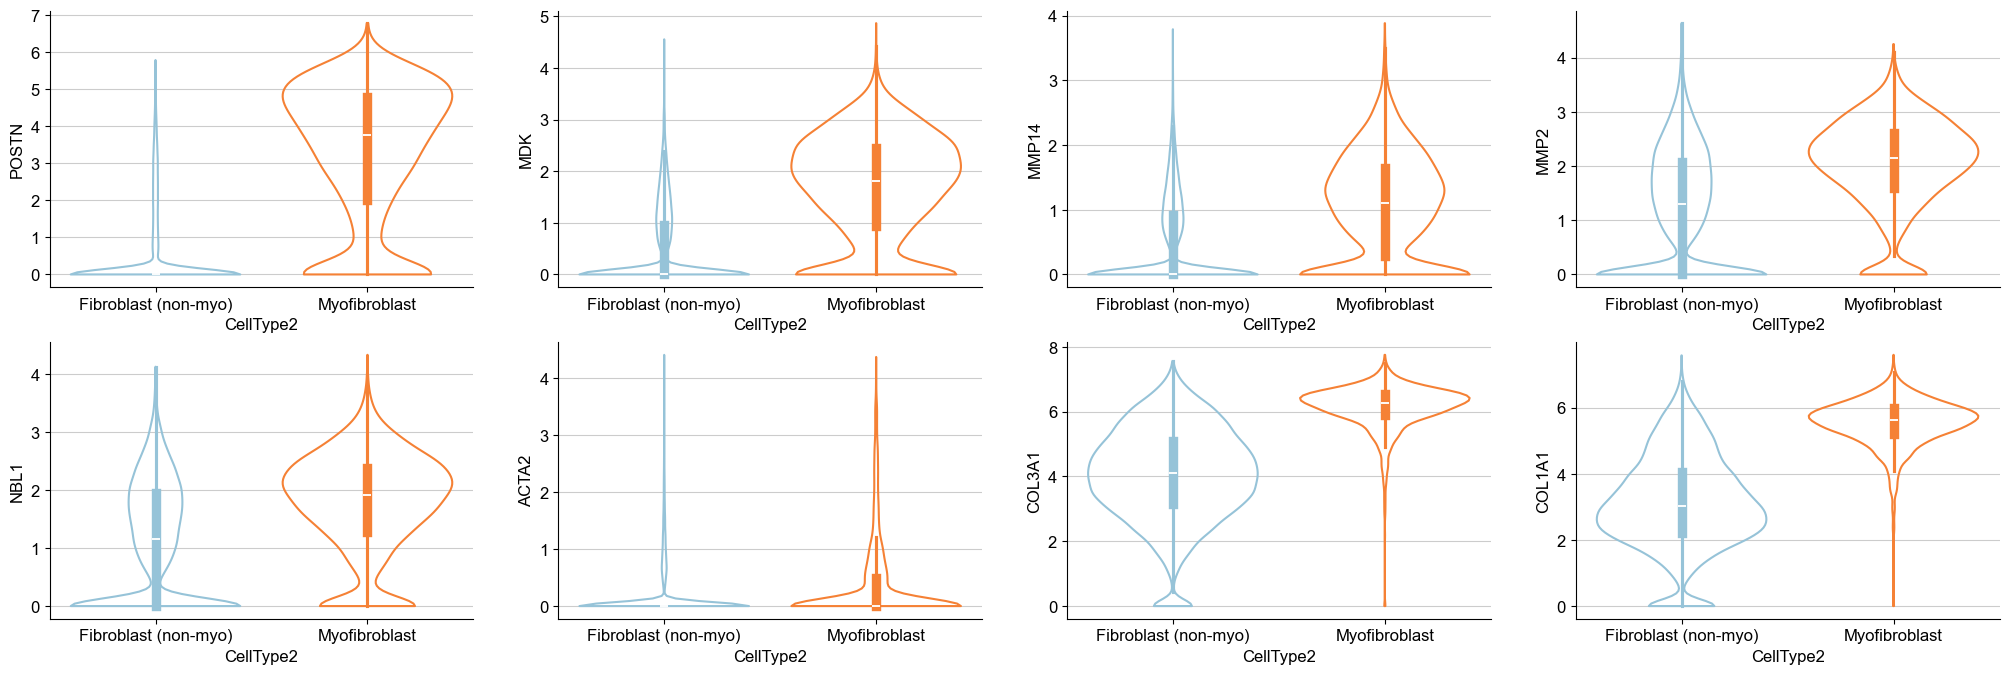

In [13]:
fig,axs = plt.subplots(2,4)
fig.set_figheight(8)
fig.set_figwidth(25)
genes = ["POSTN","MDK","MMP14","MMP2","NBL1","ACTA2","COL3A1","COL1A1"]
for i,gene in enumerate(genes):
    sc.pl.violin(adata,groupby="CellType2",keys=gene,ax=axs[int(i/4),i%4],show=False,stripplot=False,fill=False,inner="box")
fig.savefig("3.2.FigureS1G.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [14]:
markers = myutils.tl.scanpy_ranking_genes(adata,group_by="condition",calculate_average_expression=False,save="10.4.markers_fibroblast_by_condition.tsv")
markers.head(5)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


,NS_names,NS_scores,NS_pvals_adj,NS_logfoldchanges,Scar/keloid_names,Scar/keloid_scores,Scar/keloid_pvals_adj,Scar/keloid_logfoldchanges
0,DCD,89.943420,0.0,2.847825,CTHRC1,73.865158,0.0,2.845025
1,MT-ND2,57.468460,0.0,0.888191,COL1A1,65.406296,0.0,1.912576
2,CD9,51.515396,0.0,1.608223,CPXM1,63.217709,0.0,2.133599
3,MT-ATP6,46.684231,0.0,0.604226,ASPN,62.767670,0.0,3.090269
4,GSN,45.974422,0.0,1.209582,COL1A2,61.373005,0.0,1.550997


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


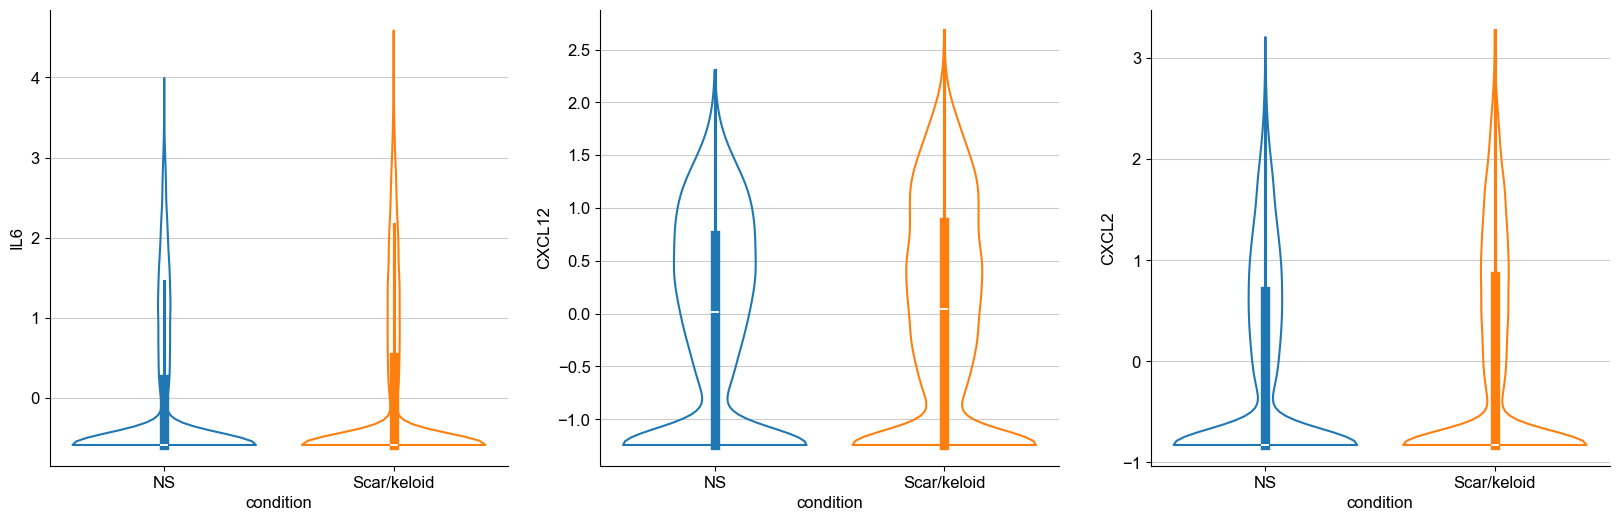

In [18]:
fig,axs = plt.subplots(1,3)
fig.set_figheight(6)
fig.set_figwidth(20)
genes = ["IL6","CXCL12","CXCL2"]
tmp = adata.copy()
sc.pp.scale(tmp)
for i,gene in enumerate(genes):
    sc.pl.violin(tmp,groupby="condition",keys=gene,ax=axs[i],show=False,stripplot=False,fill=False,inner="box")
fig.savefig("3.2.Figure1F.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [20]:
!conda list

# packages in environment at C:\Users\dell\.conda\envs\scanpy:
#
# Name                    Version                   Build  Channel
absl-py                   2.3.0                    pypi_0    pypi
adjusttext                1.3.0                    pypi_0    pypi
aiobotocore               2.5.4                    pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.12.4                   pypi_0    pypi
aioitertools              0.12.0                   pypi_0    pypi
aiosignal                 1.3.2                    pypi_0    pypi
anndata                   0.10.8                   pypi_0    pypi
anyio                     4.8.0                    pypi_0    pypi
argon2-cffi               23.1.0                   pypi_0    pypi
argon2-cffi-bindings      21.2.0                   pypi_0    pypi
array-api-compat          1.10.0                   pypi_0    pypi
arrow                     1.3.0                    pypi_0    pypi
asciitree 